In [1]:
cd ../..

/app


/usr/local/lib/python3.9/dist-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import datajoint as db

In [4]:
db.__version__

'0.12.5b1'

In [5]:
%run run.py connect

2025-01-09 11:57:31,408::INFO::settings.py::Setting loglevel to INFO
2025-01-09 11:57:31,410::INFO::settings.py::Setting stores to {}
2025-01-09 11:57:31,411::INFO::settings.py::Setting database.misc.schema_prefix to 
2025-01-09 11:57:31,412::INFO::settings.py::Setting database.misc.create_tables to True
2025-01-09 11:57:31,413::INFO::settings.py::Setting enable_python_native_blobs to True
2025-01-09 11:57:31,414::INFO::settings.py::Setting database.host to 128.178.51.167:3309
2025-01-09 11:57:31,415::INFO::settings.py::Setting database.user to thomas
2025-01-09 11:57:31,418::INFO::settings.py::Setting database.password to thomas


2025-01-09 11:57:31,471::INFO::connection.py::Connected thomas@128.178.51.167:3309
2025-01-09 11:57:31,486::INFO::table.py::could not log event in table ~log


Connecting thomas@128.178.51.167:3309


2025-01-09 11:57:31,890::INFO::table.py::could not log event in table ~log
2025-01-09 11:57:31,890::INFO::table.py::could not log event in table ~log
2025-01-09 11:57:31,909::INFO::table.py::could not log event in table ~log
2025-01-09 11:57:31,909::INFO::table.py::could not log event in table ~log
2025-01-09 11:57:31,943::INFO::table.py::could not log event in table ~log
2025-01-09 11:57:31,943::INFO::table.py::could not log event in table ~log
2025-01-09 11:57:31,977::INFO::table.py::could not log event in table ~log
2025-01-09 11:57:31,977::INFO::table.py::could not log event in table ~log


In [6]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns


from vr4mice.schema import base_analysis, dlc
from vr4mice.analysis import utils, analysis, regression, plotting
analysis.style()


In [7]:
save_fig_path =  "notebooks/Paper_figures/Figure_output/Figure3/"

In [8]:
def get_all_in_list(data_set_list, training_stage):
    print(training_stage)
    big_df = []
    
    for d in data_set_list:
        split_d = d["dataset"].split("_")
        print(split_d)
        
        offline_kinematics_df = dlc.OfflineKinematics().get_data(key=d, columns = ["head_center_x", "head_center_y", "heading_dir", "head_angle"])
        df = base_analysis.DataFrame().get_data(key=d, 
                                                        columns=[
                                                            'dataset', 'trial', 'aperture',
                                                            'trial_right_choice', 'trial_left_choice',
                                                            'velocity', 'velocity_x', 'velocity_y',
                                                            "reward",
                                                            'norm_y', "iti", "x", "y",
                                                            'trial_init_x', 'trial_init_y',
                                                            "trial_tortuosity", "trial_duration"
        ])
        df["trial_rewarded"] = base_analysis.DataFrame().get_rewarded(key=d)
        
        df = df.join(offline_kinematics_df)
        
        df["mouse_name"] = split_d[0]
        df["date"] = split_d[1]
        df["attempt"] = split_d[2]
        df["training_stage"] = training_stage
        
        big_df.append(df)
    
    big_df =  pd.concat(big_df).reset_index()
    big_df ["session_increment"] = np.array(big_df.groupby("dataset").ngroup()+1)
    big_df = big_df.infer_objects()
    
    return(big_df.reset_index(drop=True))

In [9]:
dual_occuder = [{"dataset": "Nightingale_2024-08-14_1"},
                {"dataset": "Nightingale_2024-08-13_1"},
                {"dataset": "Nightingale_2024-08-12_1"},
                {"dataset": "Nightingale_2024-08-11_1"},
                {"dataset": "Nightingale_2024-08-10_1"},
                {"dataset": "Lemming_2024-08-13_1"},
                {"dataset": "Lemming_2024-08-12_1"},
                {"dataset": "Lemming_2024-08-11_1"},
                {"dataset": "Lemming_2024-08-10_1"},
                {"dataset": "Jacana_2024-08-13_1"},
                {"dataset": "Jacana_2024-08-14_1"},
                {"dataset": "Jacana_2024-08-15_1"},
                {"dataset": "Jacana_2024-08-16_1"},
                {"dataset": "Jacana_2024-08-19_1"},
                {"dataset": "Kiwi_2024-08-10_2"},
                {"dataset": "Kiwi_2024-08-11_4"},
                {"dataset": "Kiwi_2024-08-12_2"},
                {"dataset": "Kiwi_2024-08-13_1"},
                {"dataset": "Kiwi_2024-08-14_1"},
                {"dataset": "Oribi_2024-08-16_1"},
                {"dataset": "Oribi_2024-08-19_1"},
                {"dataset": "Oribi_2024-08-20_1"},
                {"dataset": "Oribi_2024-08-21_1"},
                {"dataset": "Oribi_2024-08-22_1"},
                {"dataset": "Pheasant_2024-08-15_2"},
                {"dataset": "Pheasant_2024-08-16_1"},
                {"dataset": "Pheasant_2024-08-20_1"},
                {"dataset": "Pheasant_2024-08-21_1"},
               ]

In [10]:
#big_df = get_all_in_list(dual_occuder, training_stage="dual_occlder")
#big_df.to_pickle("notebooks/Paper_figures/dual_occluder.pickle")
big_df = pd.read_pickle("notebooks/Paper_figures/dual_occluder.pickle")
big_df = big_df [big_df.iti ==0.0]

In [ ]:
big_df["norm_x"] = big_df.groupby(["dataset", "trial"], as_index=False)["x"].transform(
        lambda x: x - np.mean(x.iloc[:3])
    )


big_df["flip_one_side"] = big_df["trial_left_choice"].replace([0, 1], [1, -1])
columns = [
    "norm_y",
    "norm_x",
    "heading_dir",
    "head_angle",
    "trial_tortuosity",
    "trial_duration",
    "x",
    "y",
    "aperture",
    "velocity",
    "velocity_x",
    "velocity_y",
    "trial_rewarded",
    "norm_y",
    "flip_one_side",
]
j_shaped = analysis.get_jshaped_trials(big_df)

#j_shaped = j_shaped[j_shaped["trial_rewarded"]==1]

n_samples = 500
interpolated_j_shaped = utils.interpolate(
    j_shaped, n_points=n_samples, value_columns=["trial_left_choice"] + columns
)
interpolated_j_shaped["trial_step"] = interpolated_j_shaped.groupby(
    ["dataset", "trial"], as_index=False).trial.cumcount()


interpolated_j_shaped["trial_length"] = interpolated_j_shaped["trial_step"] / n_samples
interpolated_j_shaped["head_angle_sin"] = np.sin(np.deg2rad(interpolated_j_shaped.head_angle))
interpolated_j_shaped["head_angle_cos"] = np.cos(np.deg2rad(interpolated_j_shaped.head_angle))

interpolated_j_shaped["heading_dir_sin"] = np.sin(np.deg2rad(interpolated_j_shaped.heading_dir))
interpolated_j_shaped["heading_dir_cos"] = np.cos(np.deg2rad(interpolated_j_shaped.heading_dir))

interpolated_j_shaped["velocity_x_fliped"] = (
    interpolated_j_shaped["velocity_x"] * interpolated_j_shaped["flip_one_side"]
)

In [ ]:
model_labels = [
    "norm_x",
    "norm_y",
    "velocity_x",
    "velocity_y",
    "heading_dir_sin",
    "heading_dir_cos",
    "head_angle_sin",
    "head_angle_cos",
    "trial_tortuosity",
    #"trial_duration",
    #"aperture",
    "trial_rewarded",
    "trial_length",
]

In [ ]:
interpolated_j_shaped["aperture"] = interpolated_j_shaped["aperture"].astype(float)

df_model, coef = regression.predict_decision(
    df=interpolated_j_shaped, label=model_labels, per_mouse=True)

Text(0.5, 0, 'Trial progression')

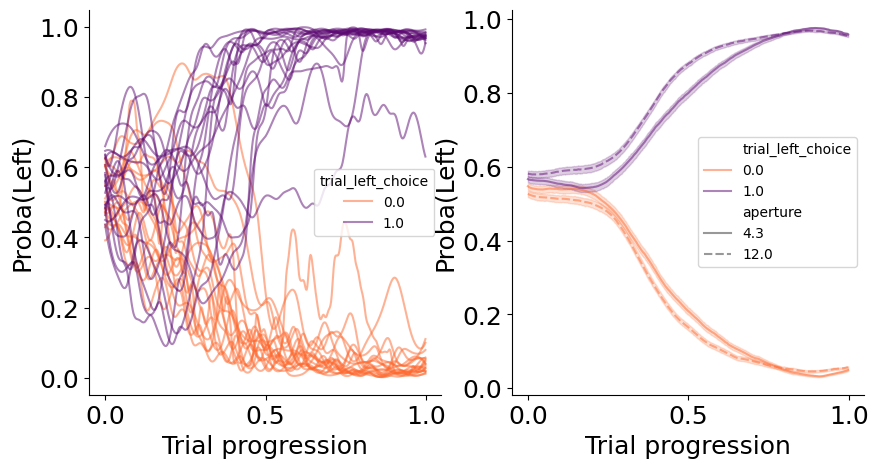

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
group = df_model[(df_model.dataset == df_model.dataset.unique()[15])]

trials = [94 , 15,  66, 170, 224, 195,  56, 203,  88, 239, 113,  91, 186, 248, 109, 164,
          188,  60, 229, 182, 156, 197,  52,  45, 110, 156, 190,  22, 210,  24,  51,  78, 
          239,  97,  24, 176, 168, 184, 123, 156]

group = group [group.trial.isin(np.array(trials))]
sns.lineplot(
        data=group,
        x="trial_length",
        y="proba_left",
        hue="trial_left_choice",
        errorbar=None,
        estimator=None,
        units="trial",
        palette= plotting.colors_choice[::-1],
        sort=False, alpha=0.5, ax=ax[0]
    )
ax[0].set_ylabel("Proba(Left)")
ax[0].set_xlabel("Trial progression")

sns.lineplot(
        data=df_model,
        x="trial_length",
        y="proba_left",
        hue="trial_left_choice",
        style="aperture",
        palette= plotting.colors_choice[::-1],
        sort=False, alpha=0.5, ax=ax[1]
    )
ax[1].set_ylabel("Proba(Left)")
ax[1].set_xlabel("Trial progression")

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

group = df_model[(df_model.dataset == df_model.dataset.unique()[15])]

trials = [94 , 15,  66, 170, 224, 195,  56, 203,  88, 239, 113,  91, 186, 248, 109, 164,
          188,  60, 229, 182, 156, 197,  52,  45, 110, 156, 190,  22, 210,  24,  51,  78, 
          239,  97,  24, 176, 168, 184, 123, 156]

group = group [group.trial.isin(np.array(trials))]
sns.lineplot(
        data=group,
        x="trial_length",
        y="proba_left",
        hue="trial_left_choice",
        errorbar=None,
        estimator=None,
        units="trial",
        palette= plotting.colors_choice[::-1],
        sort=False, alpha=0.5, ax=ax
    )
ax.set_ylabel("Prob(Left)")
ax.set_xlabel("Trial progression")
sns.despine(offset=10)
plt.savefig(save_fig_path + "dynamic_decision_variable.svg", transparent=True)

AttributeError: 'numpy.ndarray' object has no attribute 'yaxis'

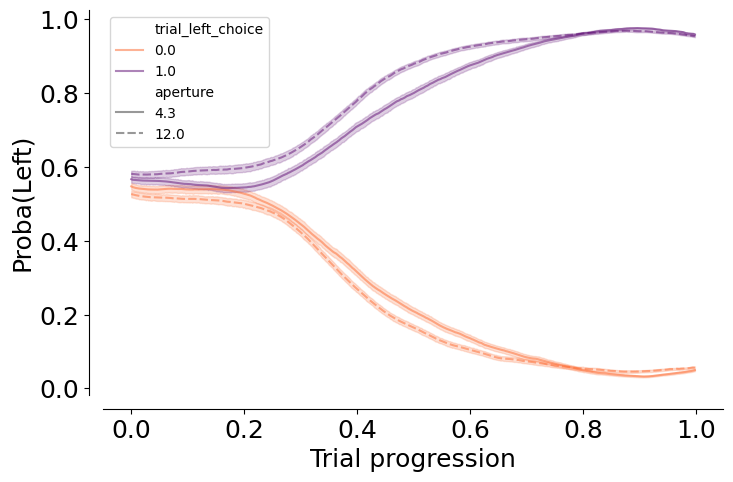

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
sns.lineplot(
        data=df_model,
        x="trial_length",
        y="proba_left",
        hue="trial_left_choice",
        style="aperture",
        palette= plotting.colors_choice[::-1],
        sort=False, alpha=0.5, ax=ax
    )
ax.set_ylabel("Proba(Left)")
ax.set_xlabel("Trial progression")
sns.despine(offset = 10)
plt.savefig(save_fig_path + "dynamic_decision_variable_mean.svg", transparent=True)

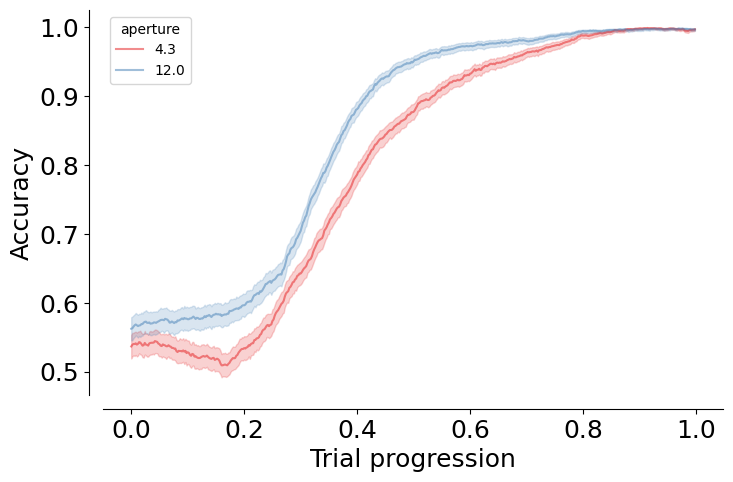

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
sns.lineplot(
        data=df_model,
        x="trial_length",
        y="accuracy",
        hue="aperture",
        palette= plotting.colors_aperture,
        sort=False, alpha=0.5, ax=ax
    )
ax.set_ylabel("Accuracy")
ax.set_xlabel("Trial progression")
sns.despine(offset=10)
plt.savefig(save_fig_path + "model_accuracy_variable.svg", transparent=True)

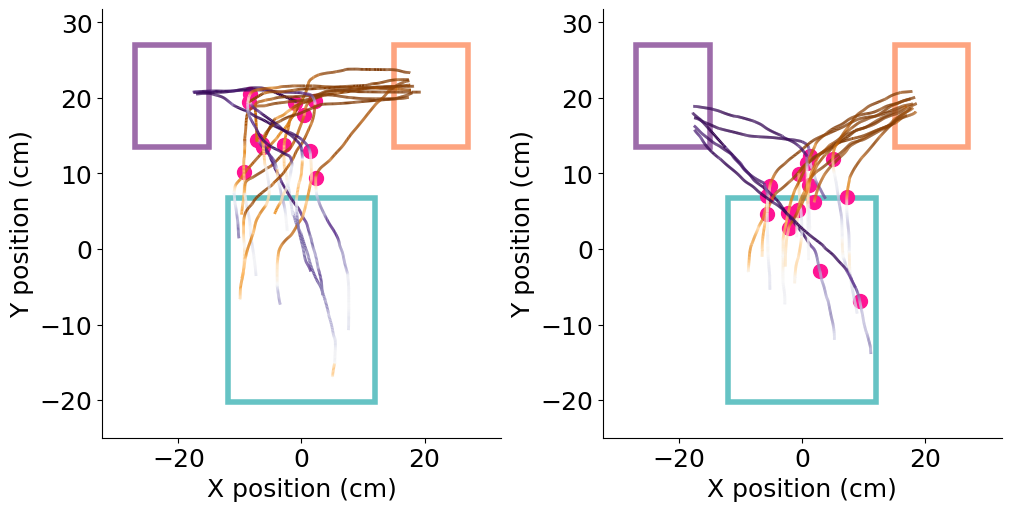

In [ ]:
df_model ["session"] = df_model ["dataset"]
df_model ["trial_L_choice"] = df_model ["trial_left_choice"]
decision_points = regression.find_decision_point(df_model, threshold_uncertainty=0.3)
fig, ax = plt.subplots(1, len(df_model.aperture.unique()), figsize=(10, 5), constrained_layout=True)

decision_color = "deeppink"
session_to_plot = "Pheasant_2024-08-15_2"#df_model.dataset.unique()[0]
box_df = base_analysis.BoxDataFrame().get_data(key={"dataset": "Pheasant_2024-08-15_2"})
#trials = [44, 45, 21, 63, 19, 30, 78, 62, 61, 45,  0, 85, 41, 43, 41, 47, 33, 50, 75, 94, 17, 83, 24, 69, 84,
#          47, 74, 30, 99, 10]

trials = [44, 45,  19,  62, 61, 45,  85, 41, 43, 41, 50, 75, 24, 69, 84,
           74,  10] + [63, 30, 78, 47, 33, 5,  17, 9,
          47,  30, 99, 11, 12, 15]


for i, aperture in enumerate(df_model.aperture.unique()):
    regression.plot_decision_points_on_trajectory(
        df_model[
            (df_model.dataset == session_to_plot) & (df_model.aperture == aperture)
        ],
        box_df,
        decision_point=decision_points[(decision_points.dataset == session_to_plot) & (decision_points.aperture == aperture)],
        color=decision_color,
        trials=trials,
        ax=ax[i],
    )
    ax[i].set_xlabel("X position (cm)")
    ax[i].set_ylabel("Y position (cm)")
plt.savefig(save_fig_path + "decisionpoints_trajectories.svg", transparent = True)

In [ ]:
decisions = decision_points.groupby(["dataset", "aperture"], as_index=False).mean()

2025-01-09 10:23:58,190::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-01-09 10:23:58,190::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-01-09 10:23:58,195::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-01-09 10:23:58,195::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-01-09 10:23:58,243::INFO::category.py::Using categorical un

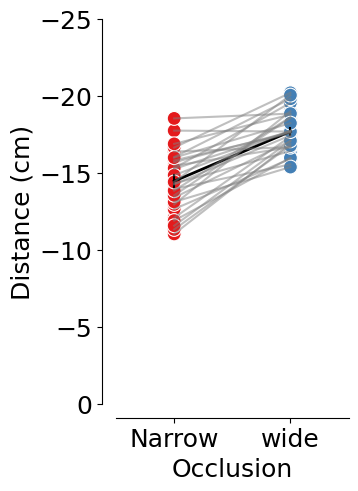

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(3,5))
counts = pd.DataFrame({"count": decisions.y-27, "dataset": decisions.dataset})

# If per_aperture, ensure aperture is formatted correctly

counts ["aperture"] = decisions.aperture.round(2).astype(str)

counts = counts.rename(columns={"trial": "count"})

plotting._plot_bar_counts(
    counts=counts,
    label_x="aperture",
    ax=ax,
    cmap=plotting.colors_aperture [:2][::-1]
)
ax.set_xlim(-.5,1.5)
ax.set_ylim(0,-25)
ax.set_xlabel("Occlusion")
ax.set_xticks([0,1], ["Narrow", "wide"])
ax.set_ylabel("Distance (cm)")
sns.despine(offset=10)
plt.savefig(save_fig_path + "decisionpoints.svg", transparent = True)


In [ ]:
from scipy.stats import ttest_rel

In [ ]:
ttest_rel(counts.y [counts.aperture  == counts.aperture.unique() [0]], counts.y [counts.aperture  == counts.aperture.unique() [1]] )

TtestResult(statistic=9.508898946003034, pvalue=4.1356311224413357e-10, df=27)

In [ ]:
counts.columns = ["y", "dataset", "aperture"]

In [ ]:
counts

,y,dataset,aperture
0,-11.033390,Jacana_2024-08-13_1,4.3
1,-16.903826,Jacana_2024-08-13_1,12.0
2,-12.085221,Jacana_2024-08-14_1,4.3
3,-17.360244,Jacana_2024-08-14_1,12.0
4,-14.253065,Jacana_2024-08-15_1,4.3
5,-17.430633,Jacana_2024-08-15_1,12.0
6,-13.951177,Jacana_2024-08-16_1,4.3
7,-15.550091,Jacana_2024-08-16_1,12.0
8,-12.645652,Jacana_2024-08-19_1,4.3
9,-15.919728,Jacana_2024-08-19_1,12.0
